In [2]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import func_stats as fs
import func_plot as fp
import matplotlib.pyplot as plt
import seaborn as sns
from brainspace.gradient import GradientMaps
import networkx as nx
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from sklearn.cluster import KMeans
from pygam import LinearGAM, s, f, l
from enigmatoolbox.permutation_testing import spin_test
import warnings
warnings.filterwarnings("ignore")

## Individual level

In [3]:
plt.rcParams["font.family"] = "Arial"

SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [4]:
spa=80
mask=9447
df_impute = pd.read_csv('../data/df_impute.csv')[:mask]
atlas = np.loadtxt('../src/fs_LR.dk.txt')
gm_ctr = np.loadtxt('../data/gm_ctr'+str(spa)+'.txt')
df_impute.loc[df_impute.DX==0, 'DX'] = -1

In [5]:
def cohen_d(m, t, x='DX', data=df_impute):
  dof = m[0].df_resid
  n1 = (data[x]==1).sum()
  n2 = (data[x]==-1).sum()
  d = (t * (n1 + n2)) / (pow(n1*n2, 0.5) * pow(dof, 0.5))
  return d

In [6]:
def save_df(model, filename, x='DX',data=df_impute):
    df_save = pd.DataFrame()
    df_save['Region'] = [label[:-9] for label in np.array(fp.region_list)]
    df_save[x+'_t'] = np.array([model[i].tvalues[x] for i in range(68)])
    df_save[x+'_p'] = np.array([model[i].pvalues[x] for i in range(68)])   
    df_save[x+'_pfdr'] = fs.fdr(np.array([model[i].pvalues[x] for i in range(68)]))
    try:
        df_save[x+'_cohen'] = [cohen_d(x=x,m=model, t=df_save[x+'_t'][i], data=data) for i in range(68)]
    except:
        pass
    df_save['age_t'] = np.array([model[i].tvalues['age'] for i in range(68)])
    df_save['age_p'] = np.array([model[i].pvalues['age'] for i in range(68)])   
    df_save['age_pfdr'] = fs.fdr(np.array([model[i].pvalues['age'] for i in range(68)]))
    df_save['sex_t'] = np.array([model[i].tvalues['sex'] for i in range(68)])
    df_save['sex_p'] = np.array([model[i].pvalues['sex'] for i in range(68)])   
    df_save['sex_pfdr'] = fs.fdr(np.array([model[i].pvalues['sex'] for i in range(68)]))
    try:
        df_save[x+'_age_t'] = np.array([model[i].tvalues[x+'_age'] for i in range(68)])
        df_save[x+'_age_p'] = np.array([model[i].pvalues[x+'_age'] for i in range(68)])   
        df_save[x+'_age_pfdr'] = fs.fdr(np.array([model[i].pvalues[x+'_age'] for i in range(68)]))
    except:
        pass
    try:
        df_save[x+'_sex_t'] = np.array([model[i].tvalues[x+'_sex'] for i in range(68)])
        df_save[x+'_sex_p'] = np.array([model[i].pvalues[x+'_sex'] for i in range(68)])   
        df_save[x+'_sex_pfdr'] = fs.fdr(np.array([model[i].pvalues[x+'_sex'] for i in range(68)]))
    except:
        pass
    df_save.to_csv(filename, index=None)

In [7]:
duration = np.array((df_impute['age'] - df_impute['AO']))
duration[duration<0] = np.nan
df_impute['duration'] = duration

In [8]:
data_g1=np.loadtxt('../results/enigma_g1/'+str(spa)+'indi_g1.txt')[:mask]
data_g2=np.loadtxt('../results/enigma_g1/'+str(spa)+'indi_g1.txt')[:mask]
length_indi = np.load('../data/length_indi_spa'+str(spa)+'.npy')[:mask]
cluster_indi = np.load('../data/cluster_indi_spa'+str(spa)+'.npy')[:mask]

g1_sig = pd.read_csv('../results/enigma_g1/'+str(spa)+'_indi_g1_dx.csv')['DX_pfdr']
g1_sig = g1_sig < 0.05
g2_sig = pd.read_csv('../results/enigma_g2/'+str(spa)+'_indi_g2_dx.csv')['DX_pfdr']
g2_sig = g2_sig < 0.05
length_sig = pd.read_csv('../results/enigma_length/'+str(spa)+'_indi_length_dx.csv')['DX_pfdr']
length_sig = length_sig < 0.05
cluster_sig = pd.read_csv('../results/enigma_cluster/'+str(spa)+'_indi_cluster_dx.csv')['DX_pfdr']
cluster_sig = cluster_sig < 0.05

## Clustering

[0.09181092 0.06131399 0.0470238  0.04200584 0.03634945 0.03372801
 0.03184272 0.02624635 0.02429487 0.0238536 ]


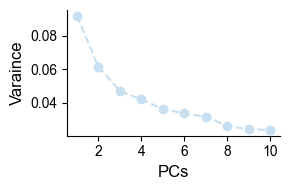

In [9]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.decomposition import PCA

data_scz = np.concatenate((data_g1, data_g2, length_indi, cluster_indi), axis=1)
data_scz_sig = data_scz[:,np.concatenate((g1_sig, g2_sig, length_sig, cluster_sig))][df_impute.DX==1]

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_scz_sig)

pca = PCA(n_components=10)
pc = pca.fit_transform(data_scaled)
print(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(3,2))

ax.plot(range(1,11), pca.explained_variance_ratio_, color='#c7dff0', marker='o', ls='--')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylabel('Varaince')
ax.set_xlabel('PCs')

fig.tight_layout()
fig.savefig('../figures/ICA_scz_sig_pca'+str(spa)+'.png', transparent=True, dpi=300)

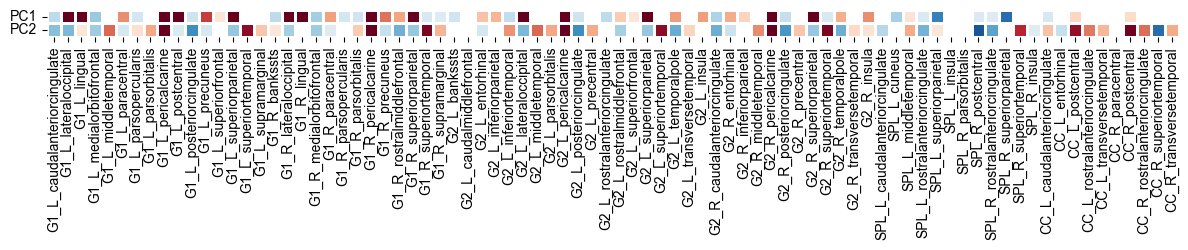

In [10]:
corr = np.zeros((2,data_scaled.shape[1],2)) # PC, feature, rp
for i in range(data_scaled.shape[1]):
    for j in range(2):
        corr[j,i] = ss.pearsonr(data_scaled[:,i], pc[:,j])

g1_label = ['G1_' + label[:-9]  for label in np.array(fp.region_list)[g1_sig]]
g2_label = ['G2_' + label[:-9] for label in np.array(fp.region_list)[g2_sig]]
spl_label = ['SPL_' + label[:-9]  for label in np.array(fp.region_list)[length_sig]]
cc_label = ['CC_' + label[:-9] for label in np.array(fp.region_list)[cluster_sig]]

fig, ax = plt.subplots(figsize=(12,2.6))
tmp = corr.copy()
tmp[:,:,0][tmp[:,:,1]>0.05/(data_scaled.shape[1]*2)] = np.nan
sns.heatmap(tmp[:,:,0], cmap='RdBu_r', vmin=-0.5, vmax=0.5, ax=ax, cbar=False,
            linewidths=1)
               
ax.set_xticks(np.arange(0.5, len(g1_label) + len(g2_label) + len(spl_label) + len(cc_label), 1))
ax.set_xticklabels(np.concatenate((g1_label, g2_label, spl_label, cc_label)), rotation=90)
ax.set_yticklabels(['PC1','PC2'], rotation=0)
fig.tight_layout()
fig.savefig('../figures/pca_feature_corr.png', transparent=True, dpi=300)

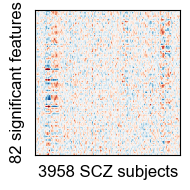

In [11]:
fig, ax = plt.subplots(figsize=(2,2))
ax.imshow(data_scaled.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_ylabel(str(data_scaled.shape[1])+' significant features')
ax.set_xlabel(str(data_scaled.shape[0]) + ' SCZ subjects')
ax.set_xticks([])
ax.set_yticks([])
fig.tight_layout()
fig.savefig('../figures/pca_feature_indi'+str(spa)+'.png', transparent=True, dpi=300)

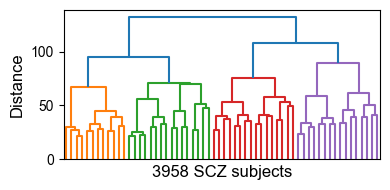

In [12]:
Z = linkage(data_scaled, method="ward")
plt.figure(figsize=(4,2))
dendrogram(Z, truncate_mode="level", p=5)
plt.xlabel(str(data_scaled.shape[0]) + ' SCZ subjects')
plt.xticks([])
plt.ylabel("Distance")

plt.tight_layout()
plt.savefig('../figures/clustering_scz_'+str(spa)+'.png', transparent=True, dpi=300)

In [13]:
from sklearn.metrics import adjusted_rand_score

def bootstrap_hc(X, K, n_boot=100):
    labels_ref = fcluster(linkage(X, "ward"), K, "maxclust")
    ari = []

    for _ in range(n_boot):
        idx = np.random.choice(len(X), len(X), replace=True)
        Xb = X[idx]
        labels_b = fcluster(linkage(Xb, "ward"), K, "maxclust")
        ari.append(adjusted_rand_score(labels_ref[idx], labels_b))

    return np.mean(ari), np.std(ari)
mean_ari = {}
std_ari = {}

for K in range(2, 10):
    mean_ari[K], std_ari[K] = bootstrap_hc(data_scaled, K=K)

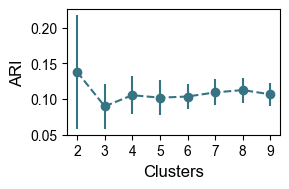

In [14]:
fig, ax = plt.subplots(figsize=(3,2))

ax.errorbar(list(mean_ari.keys()), list(mean_ari.values()), yerr=list(std_ari.values()),
            color='#377483', marker='o', ls='--')
#ax.spines['right'].set_visible(False)
#ax.spines['top'].set_visible(False)
ax.set_ylabel('ARI')
ax.set_xlabel('Clusters')
ax.set_xticks([2,3,4,5,6,7,8,9])

fig.tight_layout()
fig.savefig('../figures/adjusted_rans_score_clustering'+str(spa)+'.png', transparent=True, dpi=300)

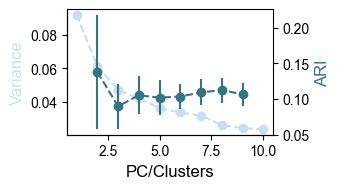

In [15]:
fig, ax = plt.subplots(figsize=(3.5,2))

line1=ax.plot(range(1,11), pca.explained_variance_ratio_, color='#c7dff0', marker='o', ls='--', label='PCA')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylabel('Variance', color='#c7dff0')
ax.set_xlabel('PC/Clusters')
ax2 = ax.twinx()
line2=ax2.errorbar(list(mean_ari.keys()), list(mean_ari.values()), yerr=list(std_ari.values()),
            color='#377483', marker='o', ls='--')
ax2.set_ylabel('ARI', color='#377483')

#lines = line1+line2
#labels = [line.get_label() for line in lines]
#ax.legend(lines, labels, loc='upper right')  

fig.tight_layout()
fig.savefig('../figures/scz_sig_pca_cluster'+str(spa)+'.png', transparent=True, dpi=300)

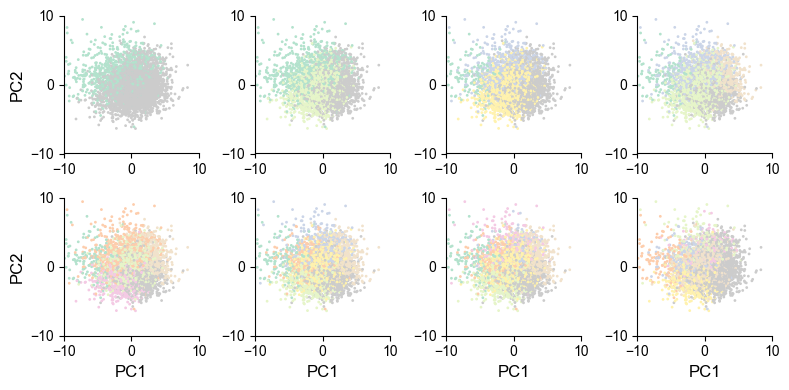

In [16]:
# choose cluster number

num = np.array([[2,3,4,5],[6,7,8,9]])
fig, ax = plt.subplots(2,4, figsize=(8,4))

for i in range(2):
  for j in range(4):
    label = fcluster(linkage(data_scaled, "ward"), num[i,j], "maxclust")
    ax[i,j].scatter(pc[:,0], pc[:,1], c=label, s=1, cmap='Pastel2')

    ax[i,j].spines['right'].set_visible(False)
    ax[i,j].spines['top'].set_visible(False)
    ax[i,j].set_xlim(-10,10)
    ax[i,j].set_ylim(-10,10)
    ax[i,j].set_xticks([-10,0,10])
    ax[i,j].set_yticks([-10,0,10])
ax[1,0].set_xlabel('PC1')
ax[1,1].set_xlabel('PC1')
ax[1,2].set_xlabel('PC1')
ax[1,3].set_xlabel('PC1')
ax[0,0].set_ylabel('PC2')
ax[1,0].set_ylabel('PC2')

fig.tight_layout()
fig.savefig('../figures/'+str(spa)+'cova_indi_similairy_subtype_clustering.png', transparent=True, dpi=300)

## kmeans

In [17]:
def bootstrap_k(X, K, n_boot=100):
    sse = []

    for _ in range(n_boot):
        idx = np.random.choice(len(X), len(X), replace=True)
        Xb = X[idx]
        kmeans = KMeans(n_clusters=K, random_state=None, n_init="auto").fit(Xb)
        sse.append(kmeans.inertia_)

    return np.mean(sse), np.std(sse)
mean_sse = {}
std_sse = {}
for i in range(8):
    mean_sse[i], std_sse[i] = bootstrap_k(data_scaled, i+2, n_boot=100)

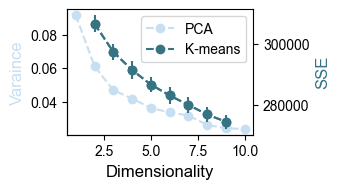

In [18]:
fig, ax = plt.subplots(figsize=(3.5,2))

line1=ax.plot(range(1,11), pca.explained_variance_ratio_, color='#c7dff0', marker='o', ls='--')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylabel('Varaince ratio')
ax.set_xlabel('Dimensionality')
ax2 = ax.twinx()
ax2.errorbar(range(2,10), list(mean_sse.values()), yerr=list(std_sse.values()),
            color='#377483', marker='o', ls='--')

line2=ax2.plot(range(2,10), list(mean_sse.values()),
            color='#377483', marker='o', ls='--')
ax2.set_ylabel('SSE', color='#377483')
ax.set_ylabel('Varaince', color='#c7dff0')

labels = ['PCA','K-means']
ax.legend([line1[0], line2[0]], labels, loc='upper right')  

fig.tight_layout()
fig.savefig('../figures/scz_sig_pca_kmeans'+str(spa)+'.png', transparent=True, dpi=300)

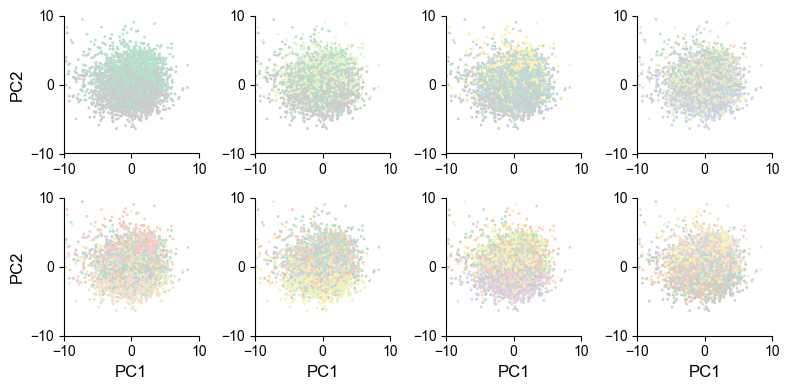

In [19]:
# choose cluster number

num = np.array([[2,3,4,5],[6,7,8,9]])
fig, ax = plt.subplots(2,4, figsize=(8,4))

for i in range(2):
  for j in range(4):
    kmeans_x = KMeans(n_clusters=num[i,j], random_state=None, n_init="auto").fit(data_scz_sig)
    label = kmeans_x.labels_
    ax[i,j].scatter(pc[:,0], pc[:,1], c=label, s=1, cmap='Pastel2')

    ax[i,j].spines['right'].set_visible(False)
    ax[i,j].spines['top'].set_visible(False)
    ax[i,j].set_xlim(-10,10)
    ax[i,j].set_ylim(-10,10)
    ax[i,j].set_xticks([-10,0,10])
    ax[i,j].set_yticks([-10,0,10])
ax[1,0].set_xlabel('PC1')
ax[1,1].set_xlabel('PC1')
ax[1,2].set_xlabel('PC1')
ax[1,3].set_xlabel('PC1')
ax[0,0].set_ylabel('PC2')
ax[1,0].set_ylabel('PC2')

fig.tight_layout()
fig.savefig('../figures/'+str(spa)+'cova_indi_similairy_subtype_kmeans.png', transparent=True, dpi=300)

In [20]:
accurancy_s0 = np.zeros(100)
accurancy_s1 = np.zeros(100)
for i in range(100):
      np.random.seed(i)
      split = np.random.randint(2, size=len(data_scz_sig))
      kmeans_0 = KMeans(n_clusters=2, n_init="auto", random_state=None).fit(data_scz_sig[split==0])
      kmeans_1 = KMeans(n_clusters=2, n_init="auto", random_state=None).fit(data_scz_sig[split==1])
      split0_T = kmeans_0.labels_
      split1_T = kmeans_1.labels_
      split0_P = kmeans_1.predict(data_scz_sig[split==0])
      split1_P = kmeans_0.predict(data_scz_sig[split==1])
      accurancy_s1[i] = (np.logical_and(split0_T==0, split0_P==0).sum() + np.logical_and(split0_T==1, split0_P==1).sum())/(split==0).sum()
      accurancy_s0[i] = (np.logical_and(split1_T==0, split1_P==0).sum() + np.logical_and(split1_T==1, split1_P==1).sum())/(split==1).sum()

np.random.seed(np.argmax(accurancy_s0 + accurancy_s1))
split = np.random.randint(2, size=len(data_scz_sig))
kmeans_0 = KMeans(n_clusters=2, n_init="auto", random_state=None).fit(data_scz_sig[split==0])
kmeans_1 = KMeans(n_clusters=2, n_init="auto", random_state=None).fit(data_scz_sig[split==1])
split0_T = kmeans_0.labels_
split1_T = kmeans_1.labels_
split0_P = kmeans_1.predict(data_scz_sig[split==0])
split1_P = kmeans_0.predict(data_scz_sig[split==1])
accurancy_1 = (np.logical_and(split0_T==0, split0_P==0).sum() + np.logical_and(split0_T==1, split0_P==1).sum())/(split==0).sum()
accurancy_0 = (np.logical_and(split1_T==0, split1_P==0).sum() + np.logical_and(split1_T==1, split1_P==1).sum())/(split==1).sum()

print('split_0: accurancy_1:', accurancy_1, 
      np.logical_and(split0_T==0, split0_P==0).sum(), 
      np.logical_and(split0_T==0, split0_P==1).sum(),
      np.logical_and(split0_T==1, split0_P==0).sum(),
      np.logical_and(split0_T==1, split0_P==1).sum(), '\n'
      'split_1: accurancy_0:', accurancy_0, 
      np.logical_and(split1_T==0, split1_P==0).sum(), 
      np.logical_and(split1_T==0, split1_P==1).sum(),
      np.logical_and(split1_T==1, split1_P==0).sum(),
      np.logical_and(split1_T==1, split1_P==1).sum())

split_0: accurancy_1: 0.9858657243816255 1063 15 13 890 
split_1: accurancy_0: 0.9883662114314619 1034 10 13 920


In [21]:
df_scz = df_impute[df_impute.DX==1].reset_index(drop=True)
#labels = fcluster(linkage(data_scaled, "ward"), 2, "maxclust")
labels = kmeans_0.predict(data_scz_sig)
subtype = labels.copy()
#subtype[subtype==2]=-1
subtype[subtype==0]=-1
print(len(subtype[subtype==1]), len(subtype[subtype==-1]))
df_scz['subtype'] = subtype
np.savetxt('../results/enigma_subtype.txt', subtype)

#df_scz.loc[df_scz.AO>df_scz.age, 'AO'] = np.nan
#dull = (df_scz.age - df_scz.AO)/df_scz.age

#df_scz['dull'] = dull
#df_scz['subtype_dull'] = subtype * df_scz.dull
df_scz['subtype_age'] = subtype * df_scz.age
df_scz['subtype_sex'] = subtype * df_scz.sex

df_scz['PC1'] = pc[:,0]
df_scz['PC2'] = pc[:,1]
df_scz

1833 2125


,site,ID,AO,IQ,CPZ,sans_total,site_num,DX,age,sex,...,R_frontalpole_thickavg,R_temporalpole_thickavg,R_transversetemporal_thickavg,R_insula_thickavg,duration,subtype,subtype_age,subtype_sex,PC1,PC2
0,01_Zurish,subj_102,31.00,NaN,150.00,41,1.0,1.0,41.0,1.0,...,2.500904,3.541187,2.137752,2.669681,10.00,-1,-41.0,-1.0,1.685627,-3.136587
1,01_Zurish,subj_104,16.80,NaN,150.00,13,1.0,1.0,19.0,1.0,...,2.634028,3.786055,2.339944,2.970092,2.20,-1,-19.0,-1.0,0.215344,-4.552013
2,01_Zurish,subj_106,25.00,NaN,150.00,44,1.0,1.0,30.0,2.0,...,2.113290,4.027056,2.583664,3.098219,5.00,-1,-30.0,-2.0,-3.059422,-2.922843
3,01_Zurish,subj_107,29.00,NaN,300.00,9,1.0,1.0,36.0,2.0,...,2.767648,3.876681,2.614507,3.180831,7.00,1,36.0,2.0,2.311514,2.253429
4,01_Zurish,subj_108,22.70,NaN,333.33,27,1.0,1.0,23.0,1.0,...,2.570538,3.593006,2.365075,3.222222,0.30,-1,-23.0,-1.0,-0.045640,0.943434
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3953,40_RSCZ,SCH42,23.38,NaN,NaN,NaN,40.0,1.0,24.0,2.0,...,2.813731,3.491770,2.419575,2.914624,0.62,-1,-24.0,-2.0,1.291114,0.890834
3954,40_RSCZ,SCH43,26.00,NaN,NaN,NaN,40.0,1.0,26.0,2.0,...,2.869550,3.148980,2.070684,2.839042,0.00,1,26.0,2.0,-1.758594,4.284054
3955,40_RSCZ,SCH44,23.09,NaN,NaN,NaN,40.0,1.0,23.0,2.0,...,2.758909,3.892109,2.364750,2.771278,NaN,-1,-23.0,-2.0,4.793581,2.975817
3956,40_RSCZ,SCH45,21.44,NaN,NaN,NaN,40.0,1.0,22.0,2.0,...,2.824696,3.857079,2.521252,3.176556,0.56,1,22.0,2.0,-2.752573,1.480720


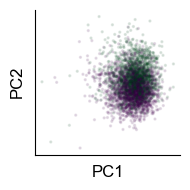

In [22]:
fig, ax = plt.subplots(figsize=(2,2))

ax.scatter(pc[:,0], pc[:,1], 
           c=subtype, s=2, cmap='PRGn', alpha=0.1)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylabel('PC2')
ax.set_xlabel('PC1')

fig.tight_layout()
fig.savefig('../figures/sse_clustering_example_png', transparent=True, dpi=300)

In [23]:
df_test=df_scz[['age','sex']].dropna()
model_demo = OLS(df_scz['PC1'][df_test.index], add_constant(df_test)).fit()
model_demo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    PC1   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     22.04
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           3.03e-10
Time:                        15:39:21   Log-Likelihood:                -9589.2
No. Observations:                3958   AIC:                         1.918e+04
Df Residuals:                    3955   BIC:                         1.920e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8189      0.170      4.823      0.000       0.486       1.152
age           -0.0237      0.004     -6.584      0.000      -0.031      -0.017
sex            0.0080      0.090      0.089      0.929      -0.169       0.185
==============================================================================
Omnibus:                      615.042   Durbin-Watson:                   1.964
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1518.389
Skew:                          -0.870   Prob(JB):                         0.00
Kurtosis:                       5.486   Cond. No.                         154.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

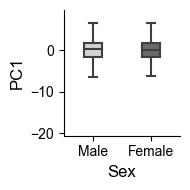

In [24]:
fig, ax = plt.subplots(figsize=(2,2))
sns.boxplot(data=df_scz, x="sex", y="PC1", ax=ax, palette=sns.color_palette(['lightgrey', 'dimgrey']),
            width=0.3, fliersize=0)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xticklabels(['Male', 'Female'])
ax.set_xlabel('Sex')
fig.tight_layout()
fig.savefig('../figures/'+str(spa)+'cova_indi_sex_pc1.png', transparent=True, dpi=300)

In [25]:
df_test=df_scz[['age','sex']].dropna()
model_demo = OLS(df_scz['PC2'][df_test.index], add_constant(df_test)).fit()
model_demo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    PC2   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.652
Date:                Tue, 10 Feb 2026   Prob (F-statistic):             0.0706
Time:                        15:39:21   Log-Likelihood:                -8809.5
No. Observations:                3958   AIC:                         1.763e+04
Df Residuals:                    3955   BIC:                         1.764e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2150      0.139      1.542      0.123      -0.058       0.488
age           -0.0068      0.003     -2.301      0.021      -0.013      -0.001
sex            0.0168      0.074      0.227      0.821      -0.129       0.163
==============================================================================
Omnibus:                      114.543   Durbin-Watson:                   1.871
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              130.246
Skew:                           0.386   Prob(JB):                     5.22e-29
Kurtosis:                       3.440   Cond. No.                         154.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [26]:
ss.pearsonr(df_scz.age, df_scz.PC1), ss.pearsonr(df_scz.age, df_scz.PC2)

(PearsonRResult(statistic=-0.10497625621188651, pvalue=3.578742382698516e-11),
 PearsonRResult(statistic=-0.03642160856243597, pvalue=0.021939369120623435))

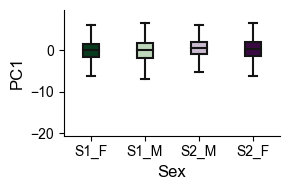

In [27]:
fig, ax = plt.subplots(figsize=(3,2))

four_c = sns.color_palette([[0,68/256,27/256],
                            [188/256,220/256,183/256],
                            [204/256,185/256,211/256],
                            [64/256,0,75/256]])
sns.boxplot(data=df_scz, x="subtype_sex", y="PC1", ax=ax, palette=four_c,
            width=0.3, fliersize=0)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xlabel('Sex')
ax.set_xticklabels(['S1_F','S1_M','S2_M','S2_F'])

fig.tight_layout()
fig.savefig('../figures/'+str(spa)+'cova_indi_subtype_sex_pc1.png', transparent=True, dpi=300)

In [28]:
df_test=df_scz[['age','sex','subtype','subtype_sex']].dropna()
model_demo = OLS(df_scz['PC1'][df_test.index], add_constant(df_test)).fit()
model_demo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    PC1   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     18.47
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           4.77e-15
Time:                        15:39:22   Log-Likelihood:                -9574.5
No. Observations:                3958   AIC:                         1.916e+04
Df Residuals:                    3953   BIC:                         1.919e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.8417      0.170      4.963      0.000       0.509       1.174
age            -0.0233      0.004     -6.477      0.000      -0.030      -0.016
sex            -0.0072      0.090     -0.080      0.936      -0.184       0.170
subtype         0.3791      0.131      2.902      0.004       0.123       0.635
subtype_sex    -0.1086      0.089     -1.213      0.225      -0.284       0.067
==============================================================================
Omnibus:                      608.614   Durbin-Watson:                   1.966
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1519.499
Skew:                          -0.858   Prob(JB):                         0.00
Kurtosis:                       5.504   Cond. No.                         156.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [29]:
df_test=df_scz[['age','sex','subtype','subtype_age']].dropna()
model_demo = OLS(df_scz['PC1'][df_test.index], add_constant(df_test)).fit()
model_demo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    PC1   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     18.17
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           8.47e-15
Time:                        15:39:22   Log-Likelihood:                -9575.1
No. Observations:                3958   AIC:                         1.916e+04
Df Residuals:                    3953   BIC:                         1.919e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.8251      0.169      4.873      0.000       0.493       1.157
age            -0.0231      0.004     -6.435      0.000      -0.030      -0.016
sex             0.0010      0.090      0.012      0.991      -0.176       0.178
subtype         0.1623      0.132      1.232      0.218      -0.096       0.421
subtype_age     0.0019      0.004      0.541      0.588      -0.005       0.009
==============================================================================
Omnibus:                      611.720   Durbin-Watson:                   1.964
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1532.495
Skew:                          -0.861   Prob(JB):                         0.00
Kurtosis:                       5.516   Cond. No.                         161.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

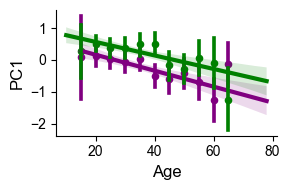

In [30]:
fig, ax = plt.subplots(figsize=(3,2))

sns.regplot(data=df_scz[df_scz.subtype==-1], x="age", y="PC1", ax=ax,
            x_bins=np.arange(15, 70, 5), color='purple',
            scatter_kws={'s':20}, line_kws={'lw':3})
sns.regplot(data=df_scz[df_scz.subtype==1], x="age", y="PC1", ax=ax,
            x_bins=np.arange(15, 70, 5), color='green',
            scatter_kws={'s':20}, line_kws={'lw':3})

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xlabel('Age')

fig.tight_layout()
fig.savefig('../figures/'+str(spa)+'cova_indi_subtype_age_pc1.png', transparent=True, dpi=300)

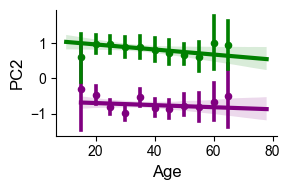

In [31]:
fig, ax = plt.subplots(figsize=(3,2))

sns.regplot(data=df_scz[df_scz.subtype==-1], x="age", y="PC2", ax=ax,
            x_bins=np.arange(15, 70, 5), color='purple',
            scatter_kws={'s':20}, line_kws={'lw':3})
sns.regplot(data=df_scz[df_scz.subtype==1], x="age", y="PC2", ax=ax,
            x_bins=np.arange(15, 70, 5), color='green',
            scatter_kws={'s':20}, line_kws={'lw':3})

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xlabel('Age')

fig.tight_layout()
fig.savefig('../figures/'+str(spa)+'cova_indi_subtype_age_pc2.png', transparent=True, dpi=300)

In [32]:
df_test=df_scz[['age','sex','subtype','subtype_age']].dropna()
model_demo = OLS(df_scz['PC2'][df_test.index], add_constant(df_test)).fit()
model_demo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    PC2   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     143.0
Date:                Tue, 10 Feb 2026   Prob (F-statistic):          2.67e-114
Time:                        15:39:22   Log-Likelihood:                -8544.8
No. Observations:                3958   AIC:                         1.710e+04
Df Residuals:                    3953   BIC:                         1.713e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.2500      0.131      1.915      0.056      -0.006       0.506
age            -0.0050      0.003     -1.791      0.073      -0.010       0.000
sex            -0.0135      0.070     -0.193      0.847      -0.150       0.123
subtype         0.8687      0.102      8.553      0.000       0.670       1.068
subtype_age    -0.0021      0.003     -0.768      0.442      -0.007       0.003
==============================================================================
Omnibus:                      135.837   Durbin-Watson:                   1.915
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              160.849
Skew:                           0.413   Prob(JB):                     1.18e-35
Kurtosis:                       3.541   Cond. No.                         161.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [33]:
df_test=df_scz[['age','sex','subtype','subtype_sex']].dropna()
model_demo = OLS(df_scz['PC2'][df_test.index], add_constant(df_test)).fit()
model_demo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    PC2   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     142.8
Date:                Tue, 10 Feb 2026   Prob (F-statistic):          3.47e-114
Time:                        15:39:22   Log-Likelihood:                -8545.1
No. Observations:                3958   AIC:                         1.710e+04
Df Residuals:                    3953   BIC:                         1.713e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.2447      0.131      1.871      0.061      -0.012       0.501
age            -0.0049      0.003     -1.766      0.078      -0.010       0.001
sex            -0.0109      0.070     -0.157      0.875      -0.148       0.126
subtype         0.7718      0.101      7.665      0.000       0.574       0.969
subtype_sex     0.0169      0.069      0.244      0.807      -0.118       0.152
==============================================================================
Omnibus:                      135.149   Durbin-Watson:                   1.915
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              159.673
Skew:                           0.413   Prob(JB):                     2.13e-35
Kurtosis:                       3.535   Cond. No.                         156.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

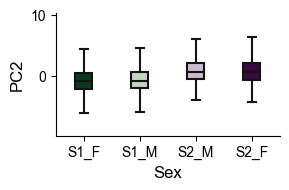

In [34]:
fig, ax = plt.subplots(figsize=(3,2))

sns.boxplot(data=df_scz, x="subtype_sex", y="PC2", ax=ax, palette=four_c,
            width=0.3, fliersize=0)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xlabel('Sex')
ax.set_xticklabels(['S1_F','S1_M','S2_M','S2_F'])

fig.tight_layout()
fig.savefig('../figures/'+str(spa)+'cova_indi_subtype_sex_pc2.png', transparent=True, dpi=300)

(29,)


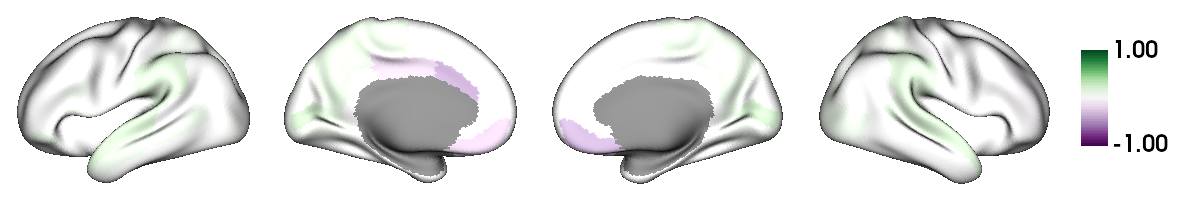

In [35]:
model = [None] * 68
for i in range(68):
  model[i] = OLS(data_g1[df_impute.DX==1][:,i], add_constant(df_scz[['age','sex','subtype']])).fit()

save_df(x='subtype', model=model,filename='../results/enigma_g1/indi_g1_subtype.csv', data=df_scz)

t = np.array([model[i].tvalues['subtype'] for i in range(68)])
cohen = np.array([cohen_d(m=model, t=t[i], x='subtype', data=df_scz) for i in range(68)])

cohen[~g1_sig] = 0

cohen[g1_sig][fs.fdr(np.array([model[i].pvalues['subtype'] for i in range(68)]))[g1_sig]>0.05] = 0
print(cohen[cohen!=0].shape)
tmp = [cohen]
plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(1200,200*len(tmp)), cmap='PRGn', color_range=(-1,1),
                display=True, filename='../figures/'+str(spa)+'indi_g1_cohen_subtype.png')

(31,)


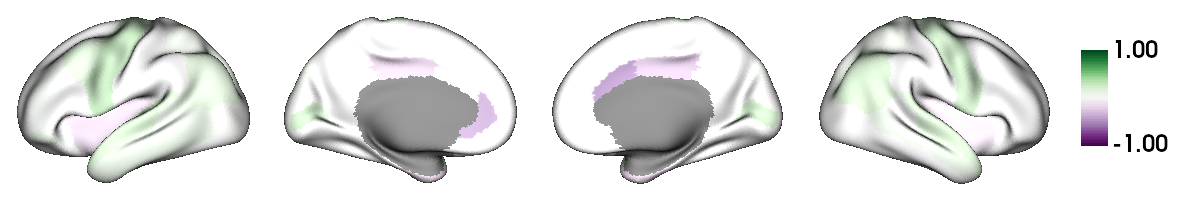

In [36]:
model = [None] * 68
for i in range(68):
  model[i] = OLS(data_g2[df_impute.DX==1][:,i], add_constant(df_scz[['age','sex','subtype']])).fit()

save_df(x='subtype', model=model,filename='../results/enigma_g2/indi_g2_subtype.csv', data=df_scz)

t = np.array([model[i].tvalues['subtype'] for i in range(68)])
cohen = np.array([cohen_d(m=model, t=t[i], x='subtype', data=df_scz) for i in range(68)])
cohen[~g2_sig] = 0
cohen[g2_sig][fs.fdr(np.array([model[i].pvalues['subtype'] for i in range(68)]))[g2_sig]>0.05] = 0
print(cohen[cohen!=0].shape)
tmp = [cohen]
plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(1200,200*len(tmp)), cmap='PRGn', color_range=(-1,1),
                display=True, filename='../figures/'+str(spa)+'indi_g2_cohen_subtype.png')

(12,)


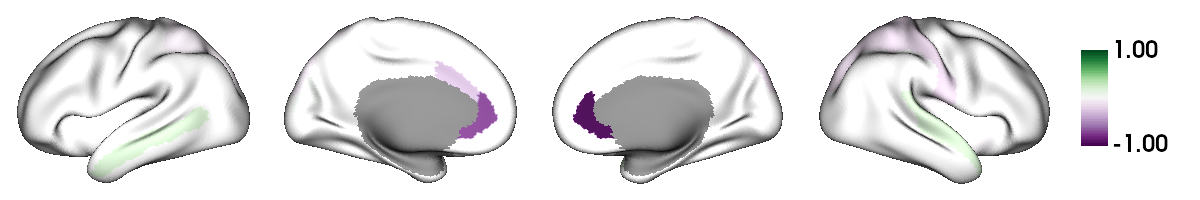

In [37]:
model = [None] * 68
for i in range(68):
  model[i] = OLS(length_indi[df_impute.DX==1][:,i], add_constant(df_scz[['age','sex','subtype']])).fit()

save_df(x='subtype', model=model,filename='../results/enigma_length/indi_length_subtype.csv', data=df_scz)

t = np.array([model[i].tvalues['subtype'] for i in range(68)])
cohen = np.array([cohen_d(m=model, t=t[i], x='subtype', data=df_scz) for i in range(68)])
cohen[~length_sig] = 0
cohen[length_sig][fs.fdr(np.array([model[i].pvalues['subtype'] for i in range(68)]))[length_sig]>0.05] = 0
print(cohen[cohen!=0].shape)
tmp = [cohen]
plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(1200,200*len(tmp)), cmap='PRGn', color_range=(-1,1),
                display=True, filename='../figures/'+str(spa)+'indi_length_cohen_subtype.png')

(10,)


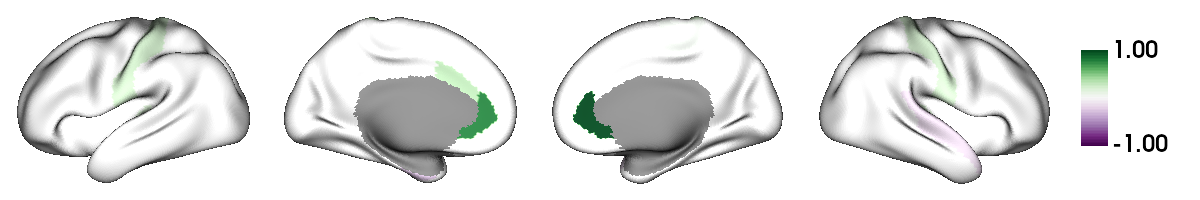

In [38]:
model = [None] * 68
for i in range(68):
  model[i] = OLS(cluster_indi[df_impute.DX==1][:,i], add_constant(df_scz[['age','sex','subtype']])).fit()

save_df(x='subtype', model=model,filename='../results/enigma_cluster/indi_cluster_subtype.csv', data=df_scz)

t = np.array([model[i].tvalues['subtype'] for i in range(68)])
cohen = np.array([cohen_d(m=model, t=t[i], x='subtype', data=df_scz) for i in range(68)])
cohen[~cluster_sig] = 0
cohen[cluster_sig][fs.fdr(np.array([model[i].pvalues['subtype'] for i in range(68)]))[cluster_sig]>0.05] = 0
print(cohen[cohen!=0].shape)
tmp = [cohen]
plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(1200,200*len(tmp)), cmap='PRGn', color_range=(-1,1),
                display=True, filename='../figures/'+str(spa)+'indi_cluster_cohen_subtype.png')